# Compare Si(Li) Sum Spectra: `22Na_b0` vs `22Na_b1`

Compare the Si(Li) summed-energy spectrum for two `22Na` simulations after requiring the two opposing HPGe detectors to both contain a full-energy 511 keV deposit. `HPGe_3` is intentionally ignored in the gate.


## Workflow

- Load `output/22Na_b0.parquet` and `output/22Na_b1.parquet` with Polars.
- Apply the gate `HPGe_1 = 511 keV` and `HPGe_2 = 511 keV`.
- Do not apply any condition on `HPGe_3`.
- Compare raw and area-normalized Si(Li) summed spectra.
- Plot the `b1 / b0` shape ratio and simple difference diagnostics.


In [39]:
from __future__ import annotations

import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import numpy as np
import polars as pl
import matplotlib
try:
    IN_NOTEBOOK = "IPKernelApp" in get_ipython().config
except Exception:
    IN_NOTEBOOK = False

if IN_NOTEBOOK:
    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        pass
else:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [59]:
# Paths and analysis settings
NOTEBOOK_PATH = Path.cwd()
REPO_ROOT = NOTEBOOK_PATH
if not (REPO_ROOT / "output").exists():
    REPO_ROOT = NOTEBOOK_PATH.parents[1]

DATA_FILES = {
    "b0": REPO_ROOT / "output" / "22Na_b0.parquet",
    "b1": REPO_ROOT / "output" / "22Na_b1.parquet",
}
FIG_DIR = REPO_ROOT / "output" / "notebook_figures" / "b0_b1_511_gate"
FIG_DIR.mkdir(parents=True, exist_ok=True)

HPGE_511_WINDOW = (508.0, 514.0)
SILI_RANGE_KEV = (0.0, 900.0)
SILI_BIN_WIDTH_KEV = 5.0
SILI_BINS = np.arange(SILI_RANGE_KEV[0], SILI_RANGE_KEV[1] + SILI_BIN_WIDTH_KEV, SILI_BIN_WIDTH_KEV)
SILI_CENTERS = 0.5 * (SILI_BINS[:-1] + SILI_BINS[1:])

print("Input files:")
for label, path in DATA_FILES.items():
    print(f"  {label}: {path}")
print(f"Figures: {FIG_DIR}")

Input files:
  b0: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/22Na_b0.parquet
  b1: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/22Na_b1.parquet
Figures: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/b0_b1_511_gate


In [60]:
def savefig(fig, name):
    path = FIG_DIR / name
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    print(f"saved {path}")


def in_window_expr(column, window):
    lo, hi = window
    return (pl.col(column) >= lo) & (pl.col(column) <= hi)


def effective_entries(weights):
    weights = np.asarray(weights, dtype=float)
    sumw = weights.sum()
    sumw2 = np.square(weights).sum()
    return float(sumw * sumw / sumw2) if sumw2 > 0 else 0.0


def load_gated_sample(path):
    needed = [
        "eventID",
        "event_weight",
        "E_SiLi_sum_keV",
        "E_HPGe_1_keV",
        "E_HPGe_2_keV",
        "E_HPGe_3_keV",
    ]
    scan = pl.scan_parquet(path)
    available = set(scan.collect_schema().names())
    missing = [name for name in needed if name not in available]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")

    gate_expr = in_window_expr("E_HPGe_1_keV", HPGE_511_WINDOW) & in_window_expr("E_HPGe_2_keV", HPGE_511_WINDOW)
    table = (
        scan.select(needed)
        .with_columns(
            gate_511_511=gate_expr,
            sili_nonzero=pl.col("E_SiLi_sum_keV") > 0,
        )
        .collect()
    )
    gated = table.filter(pl.col("gate_511_511"))
    gated_sili = gated.filter(pl.col("E_SiLi_sum_keV") > 0)

    values = gated_sili.get_column("E_SiLi_sum_keV").to_numpy()
    weights = gated_sili.get_column("event_weight").cast(pl.Float64).to_numpy()
    if not np.isfinite(weights).all() or np.all(weights == 0):
        weights = np.ones_like(values, dtype=float)

    return {
        "table": table,
        "gated": gated,
        "gated_sili": gated_sili,
        "values": values,
        "weights": weights,
        "total_events": table.height,
        "gated_events": gated.height,
        "gated_sili_events": gated_sili.height,
        "weighted_gated_sili_events": float(weights.sum()),
        "effective_gated_sili_events": effective_entries(weights),
    }


def weighted_hist(values, weights=None, bins=SILI_BINS):
    values = np.asarray(values, dtype=float)
    if weights is not None:
        weights = np.asarray(weights, dtype=float)
    counts, _ = np.histogram(values, bins=bins, weights=weights)
    if weights is None:
        variances, _ = np.histogram(values, bins=bins)
    else:
        variances, _ = np.histogram(values, bins=bins, weights=np.square(weights))
    return counts.astype(float), variances.astype(float)


def normalized(counts):
    total = float(np.sum(counts))
    return counts / total if total > 0 else np.full_like(counts, np.nan, dtype=float)

In [61]:
samples = {label: load_gated_sample(path) for label, path in DATA_FILES.items()}

summary = pl.DataFrame({
    "sample": list(samples),
    "total_events": [samples[label]["total_events"] for label in samples],
    "raw_511_511_gate_events": [samples[label]["gated_events"] for label in samples],
    "raw_511_511_gate_with_sili": [samples[label]["gated_sili_events"] for label in samples],
    "weighted_511_511_gate_with_sili": [samples[label]["weighted_gated_sili_events"] for label in samples],
    "effective_511_511_gate_with_sili": [samples[label]["effective_gated_sili_events"] for label in samples],
}).with_columns(
    raw_gate_fraction=pl.col("raw_511_511_gate_events") / pl.col("total_events"),
    raw_gate_sili_fraction=pl.col("raw_511_511_gate_with_sili") / pl.col("total_events"),
)
display(summary)

sample,total_events,raw_511_511_gate_events,raw_511_511_gate_with_sili,weighted_511_511_gate_with_sili,effective_511_511_gate_with_sili,raw_gate_fraction,raw_gate_sili_fraction
str,i64,i64,i64,f64,f64,f64,f64
"""b0""",100000000,858371,839410,839410.0,839410.0,0.008584,0.0083941
"""b1""",100000000,862429,841710,841710.0,841710.0,0.008624,0.0084171


saved /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/b0_b1_511_gate/sili_sum_b0_b1_back_to_back_511_raw.png


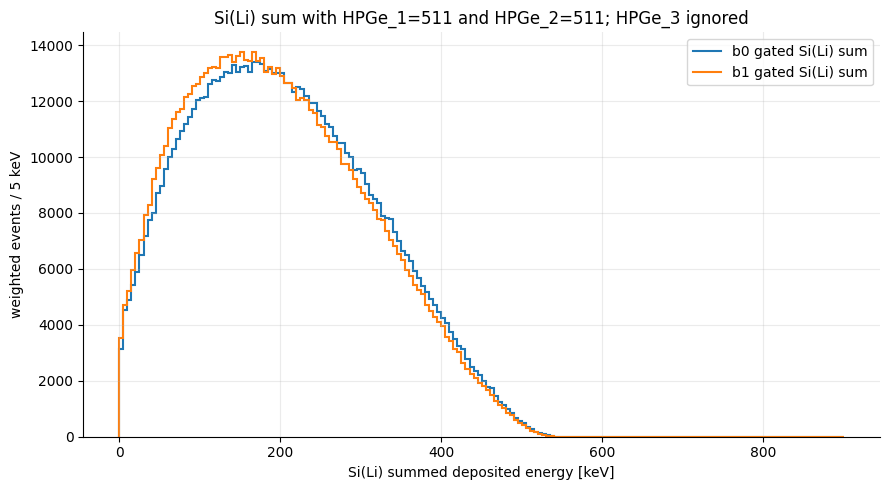

In [62]:
for sample in samples.values():
    counts, variances = weighted_hist(sample["values"], sample["weights"])
    sample["counts"] = counts
    sample["variances"] = variances
    sample["norm_counts"] = normalized(counts)

fig, ax = plt.subplots(figsize=(9, 5))
for label, sample in samples.items():
    ax.stairs(sample["counts"], SILI_BINS, linewidth=1.5, label=f"{label} gated Si(Li) sum")
ax.set_xlabel("Si(Li) summed deposited energy [keV]")
ax.set_ylabel(f"weighted events / {SILI_BIN_WIDTH_KEV:g} keV")
#ax.set_yscale("log")
ax.set_title("Si(Li) sum with HPGe_1=511 and HPGe_2=511; HPGe_3 ignored")
ax.legend()
savefig(fig, "sili_sum_b0_b1_back_to_back_511_raw.png")

saved /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/b0_b1_511_gate/sili_sum_b0_b1_back_to_back_511_normalized.png


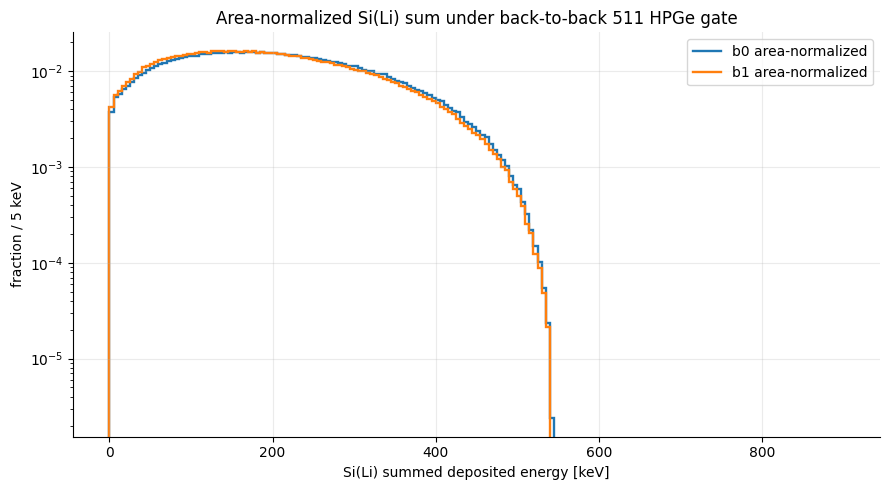

In [63]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, sample in samples.items():
    ax.stairs(sample["norm_counts"], SILI_BINS, linewidth=1.7, label=f"{label} area-normalized")
ax.set_xlabel("Si(Li) summed deposited energy [keV]")
ax.set_ylabel(f"fraction / {SILI_BIN_WIDTH_KEV:g} keV")
ax.set_yscale("log")
ax.set_title("Area-normalized Si(Li) sum under back-to-back 511 HPGe gate")
ax.legend()
savefig(fig, "sili_sum_b0_b1_back_to_back_511_normalized.png")

saved /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/b0_b1_511_gate/sili_sum_b0_b1_back_to_back_511_ratio_difference.png


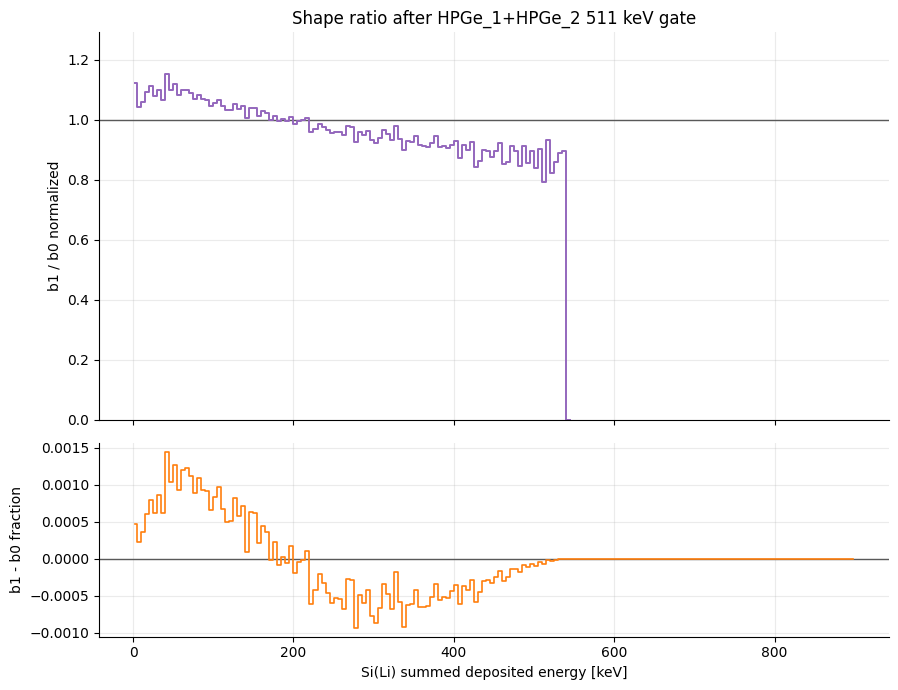

In [64]:
b0 = samples["b0"]
b1 = samples["b1"]
ratio = np.divide(
    b1["norm_counts"],
    b0["norm_counts"],
    out=np.full_like(b1["norm_counts"], np.nan, dtype=float),
    where=np.isfinite(b0["norm_counts"]) & (b0["norm_counts"] > 0),
)
raw_difference = b1["counts"] - b0["counts"]
normalized_difference = b1["norm_counts"] - b0["norm_counts"]

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, height_ratios=[2, 1])
axes[0].axhline(1.0, color="0.35", linewidth=1)
axes[0].plot(SILI_CENTERS, ratio, drawstyle="steps-mid", color="tab:purple", linewidth=1.4)
axes[0].set_ylabel("b1 / b0 normalized")
axes[0].set_title("Shape ratio after HPGe_1+HPGe_2 511 keV gate")
axes[0].set_ylim(0, np.nanpercentile(ratio[np.isfinite(ratio)], 99) * 1.15 if np.isfinite(ratio).any() else 2)

axes[1].axhline(0.0, color="0.35", linewidth=1)
axes[1].plot(SILI_CENTERS, normalized_difference, drawstyle="steps-mid", color="tab:orange", linewidth=1.2)
axes[1].set_xlabel("Si(Li) summed deposited energy [keV]")
axes[1].set_ylabel("b1 - b0 fraction")
savefig(fig, "sili_sum_b0_b1_back_to_back_511_ratio_difference.png")

In [65]:
comparison_table = pl.DataFrame({
    "bin_center_keV": SILI_CENTERS,
    "b0_weighted_counts": b0["counts"],
    "b1_weighted_counts": b1["counts"],
    "b0_fraction": b0["norm_counts"],
    "b1_fraction": b1["norm_counts"],
    "b1_over_b0_fraction": ratio,
    "b1_minus_b0_fraction": normalized_difference,
})

summary_windows = [(0, 100), (100, 250), (250, 545), (545, 900)]
window_rows = []
for lo, hi in summary_windows:
    mask = (SILI_CENTERS >= lo) & (SILI_CENTERS < hi)
    b0_counts = float(np.nansum(b0["counts"][mask]))
    b1_counts = float(np.nansum(b1["counts"][mask]))
    b0_frac = float(np.nansum(b0["norm_counts"][mask]))
    b1_frac = float(np.nansum(b1["norm_counts"][mask]))
    window_rows.append({
        "window_keV": f"{lo:g}-{hi:g}",
        "b0_weighted_counts": b0_counts,
        "b1_weighted_counts": b1_counts,
        "b0_fraction": b0_frac,
        "b1_fraction": b1_frac,
        "b1_over_b0_fraction": b1_frac / b0_frac if b0_frac > 0 else np.nan,
        "b1_minus_b0_fraction": b1_frac - b0_frac,
    })
window_summary = pl.DataFrame(window_rows)
display(window_summary)

window_keV,b0_weighted_counts,b1_weighted_counts,b0_fraction,b1_fraction,b1_over_b0_fraction,b1_minus_b0_fraction
str,f64,f64,f64,f64,f64,f64
"""0-100""",168792.0,183768.0,0.201084,0.218327,1.08575,0.017243
"""100-250""",382753.0,388380.0,0.455979,0.461418,1.011929,0.005439
"""250-545""",287865.0,269562.0,0.342937,0.320255,0.933859,-0.022682
"""545-900""",0.0,0.0,0.0,0.0,NaN,0.0


In [66]:
# Optional: write compact CSV tables for external checks.
comparison_csv = FIG_DIR / "sili_sum_b0_b1_511_gate_binned_comparison.csv"
window_csv = FIG_DIR / "sili_sum_b0_b1_511_gate_window_summary.csv"
comparison_table.write_csv(comparison_csv)
window_summary.write_csv(window_csv)
print(f"wrote {comparison_csv}")
print(f"wrote {window_csv}")

wrote /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/b0_b1_511_gate/sili_sum_b0_b1_511_gate_binned_comparison.csv
wrote /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/b0_b1_511_gate/sili_sum_b0_b1_511_gate_window_summary.csv
